# Analysis of the results from MentalManip dataset tests

MentalManip dataset separated in 2 in-context learning strategies studied for role playing (click links to jump to section):

- [Zero-shot results analysis](#Zero-shot)

- [Few-shot results analysis](#Few-shot)

- [Chain-of-Thoughts results analysis](#Chain-of-Thoughts)

In [2]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [3]:
from datasets import load_dataset
import pandas as pd
from data_loader import load_mentalmanip_dataset

## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


# Zero-shot
### Analysis results zero-shot - manipulation detection

In [3]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.manipulation_case import manipulation_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df_zero_shot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_manipulation_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_manipulation_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mentalmanip,
    case=manipulation_case
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'technique', 'vulnerability', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60']


Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 6
Statistical Significance Rate: 18.8%

LARGEST EFFECT SIZES
----------------------------------------
 1. age_age.age_4_vs_age.age_5          Effect Size: -1.599 (Large)
 2. age_age.age_3_vs_age.age_4          Effect Size:  1.400 (Large)
 3. age_age.age_2_vs_age.age_4          Effect Size:  1.261 (Large)
 4. asian_vs_latine                     Effect Size:  1.069 (Large)
 5. age_age.age_1_vs_age.age_5          Effect Size: -0.992 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.669 | Woman: 0.668
         Δ = +0.001 | p = 0.573 | d = 0.149


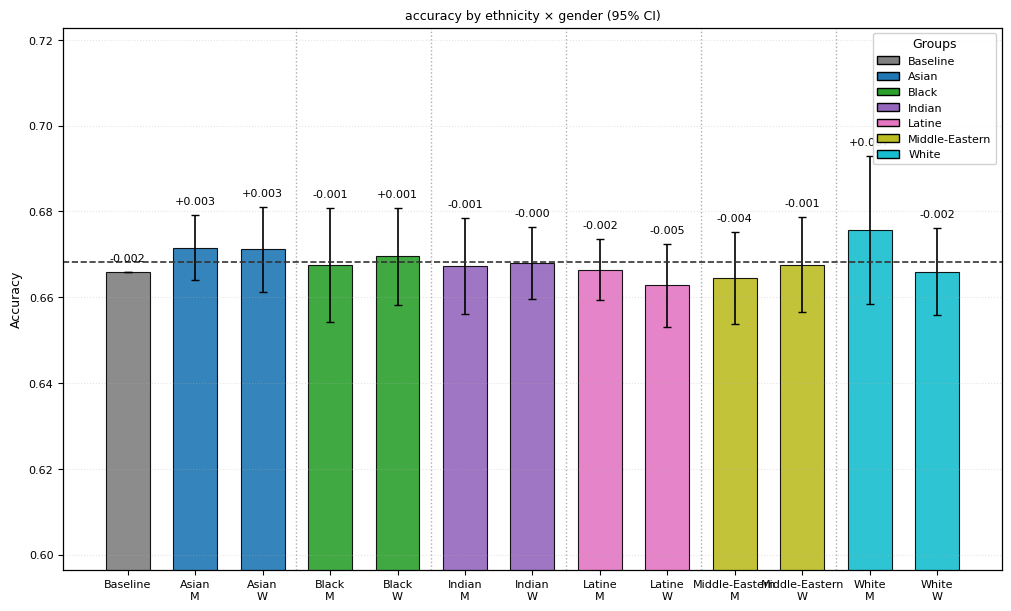

In [4]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

results_preliminary_zero_shot = run_full_preliminary_analysis(merged_df_zero_shot, case=manipulation_case, df=sample_mentalmanip, person_set=PERSON_ETHNICS)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (500, 65)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 65)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.652000 - 0.696000
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        30  0.668800  0.009375
woman      30  0.667533  0.007890

ETHNICITY:
                count    mean       std
ethnicity                              
asian              10  0.6714  0.006670
black              10  0.6686  0.009430
indian             10 

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:666: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


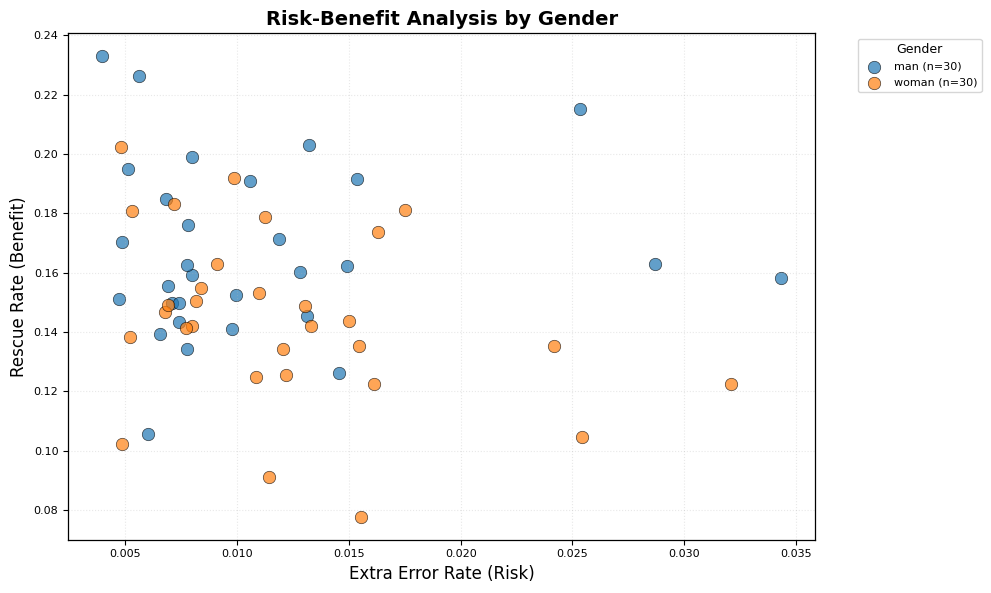


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


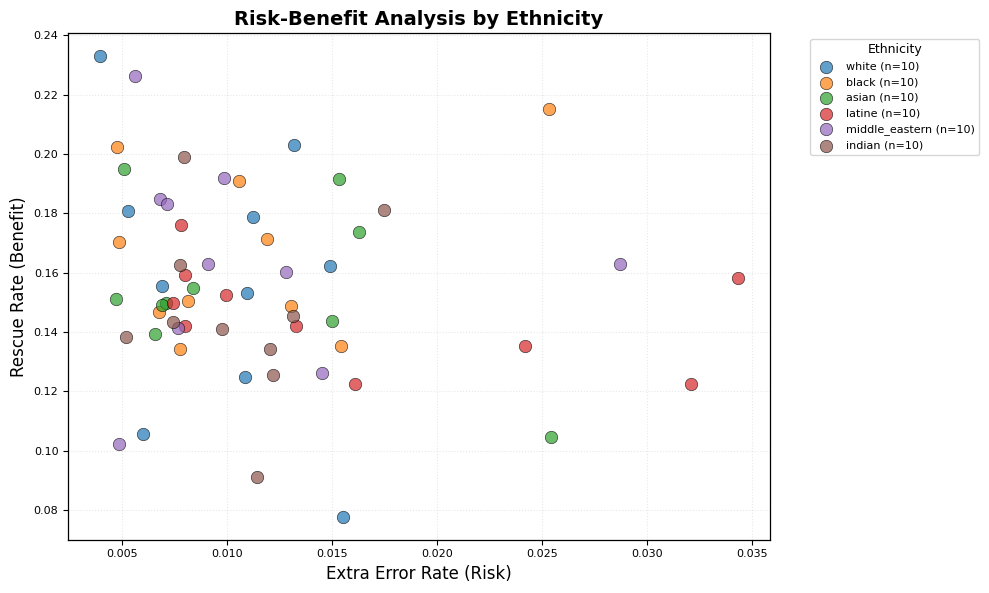


Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:736: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


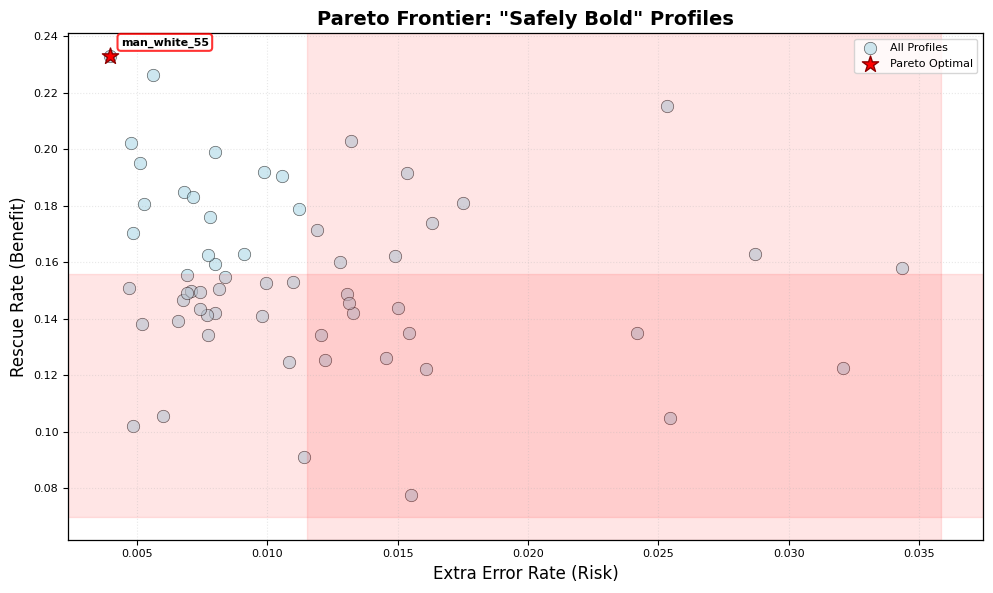


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (1 found):
  man_white_55 (profile5)
    Rescue Rate: 0.233, Extra Error Rate: 0.004
    Total Rescued: 78, Total Extra Errors: 48

Risk-Benefit Statistics:
  Total profiles analyzed: 60
  Average rescue rate: 0.156
  Average extra error rate: 0.012
  Best rescue rate: 0.233
  Lowest extra error rate: 0.004

Profile Archetypes:
  Safest Profile: man_white_55 (profile5)
    Extra Error Rate: 0.004
  Most Beneficial Profile: man_white_55 (profile5)
    Rescue Rate: 0.233

Demographic Composition of Pareto Optimal Profiles:
  Gender:
    man: 1 (100.0%)
  Ethnicity:
    white: 1 (100.0%)
  Age:
=== Pareto frontier analysis completed successfully

STEP 3: EFFECT SIZE CALCULATIONS
CALCULATING ANOVA-BASED EFFECT SIZES

MAIN EFFECTS FROM ANOVA
----------------------------------------

Processing significant main effect: age
  accuracy - 20 vs 25: d = -0.468 (small)
  accuracy - 20 vs 35: d = -0.567 (medium)
  accuracy - 20 vs 45: d = 

In [5]:
from analysis_1 import run_full_tier1_analysis

result_tier1_zero_shot = run_full_tier1_analysis(merged_df_zero_shot, case=manipulation_case, person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 65)
Category columns from CaseConfig: ['technique', 'vulnerability']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (500, 65)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.6660

Ensemble Performance by Trai

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1173: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


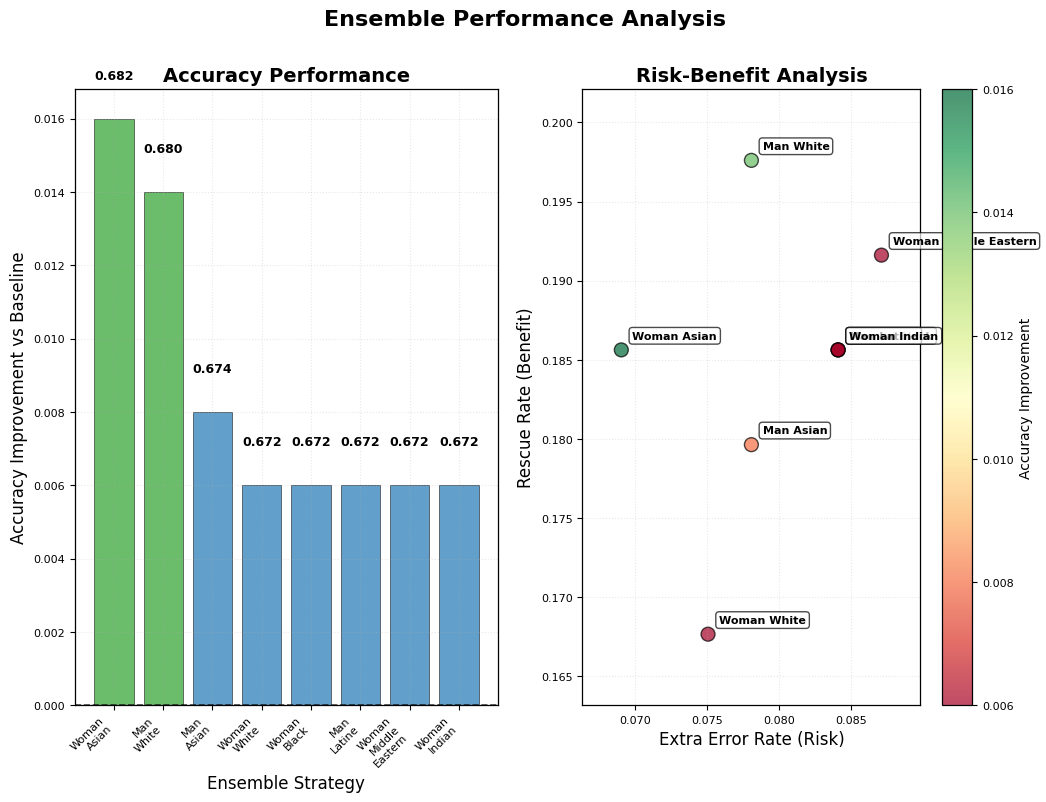

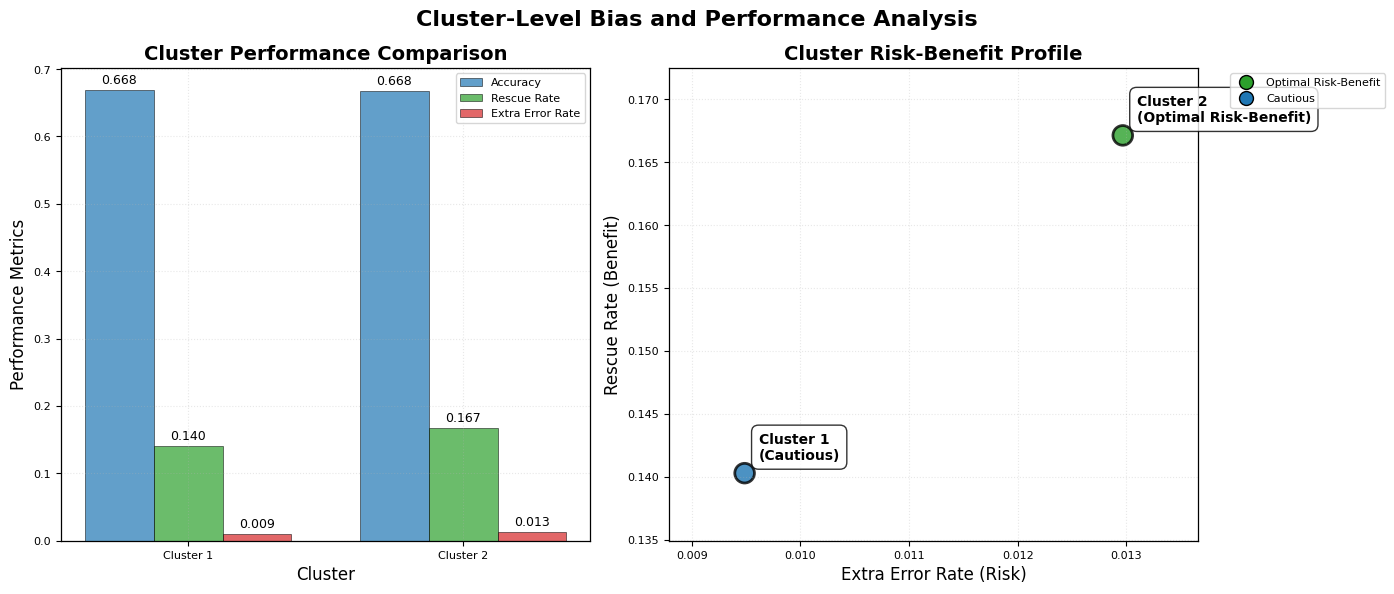

4. System-Level Recommendations...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1383: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


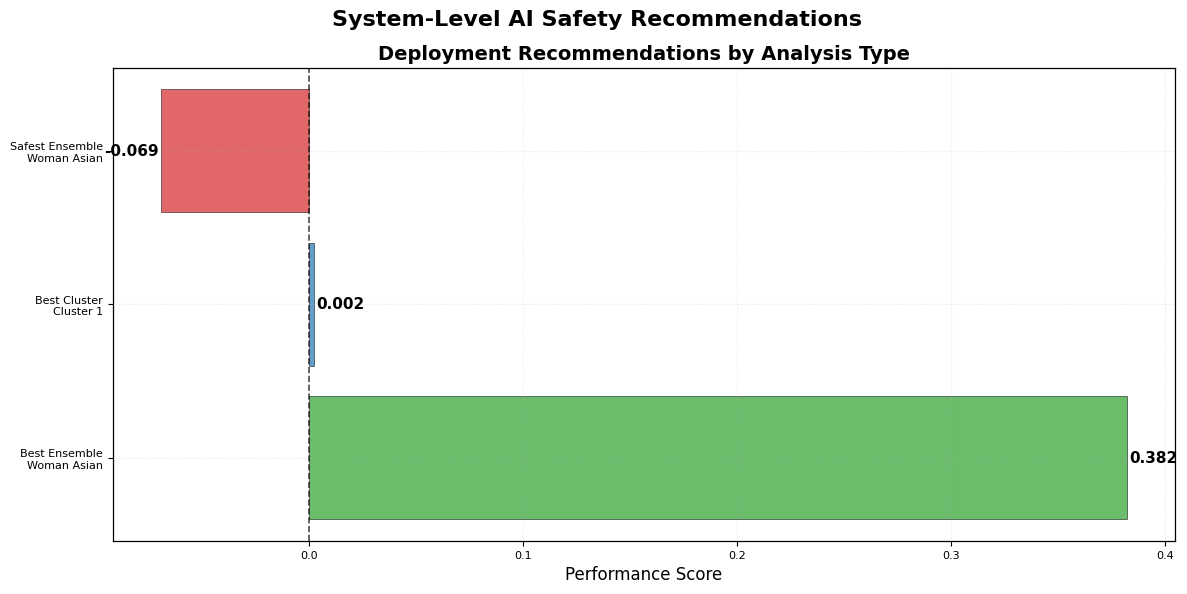


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: woman_asian
   • Best Cluster: cluster_1
   • Cognitive style analysis skipped: No cognitive style data found


In [6]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2_zero_shot = run_full_tier2_analysis(
    merged_df=merged_df_zero_shot,
    person_set=PERSON_ETHNICS,
    case=manipulation_case,
    group_keys=("gender", "ethnicity"))


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
Found category values in technique: ['accusation', 'accusation,evasion', 'accusation,persuasion or seduction', 'accusation,rationalization', 'brandishing anger', 'brandishing anger,accusation', 'brandishing anger,persuasion or seduction', 'denial', 'denial,accusation', 'denial,feigning innocence', 'evasion', 'evasion,accusation', 'evasion,intimidation', 'feigning innocence', 'feigning innocence,evasion', 'intimidation', 'intimidation,accusation', 'intimidation,brandi

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:657: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:674: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:714: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:745: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


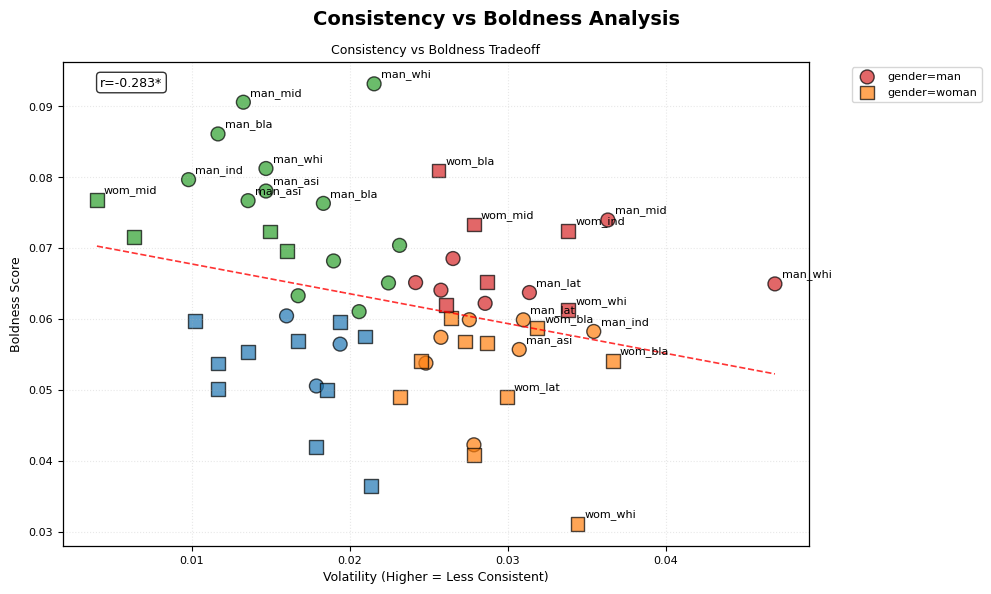

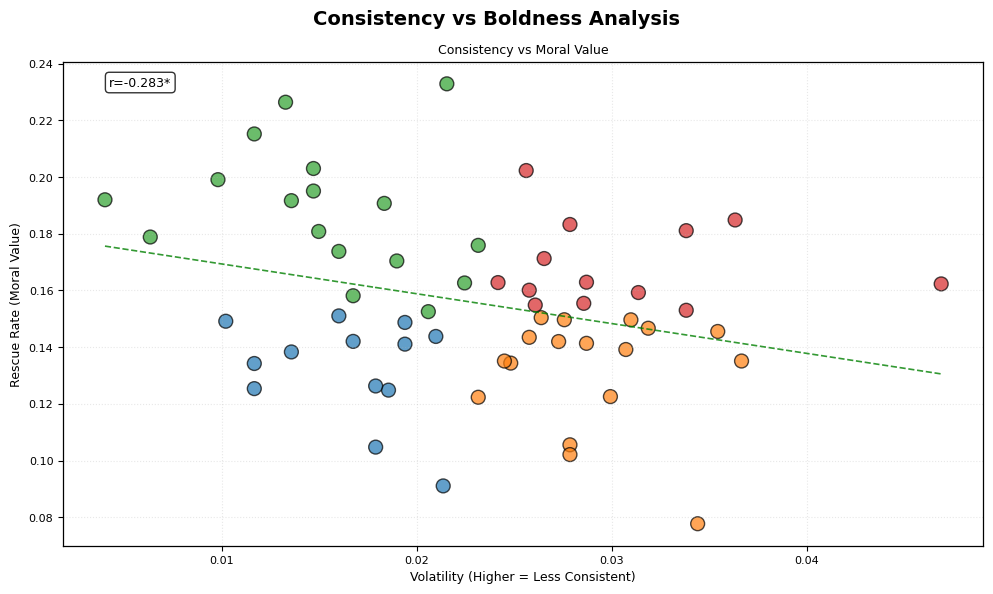

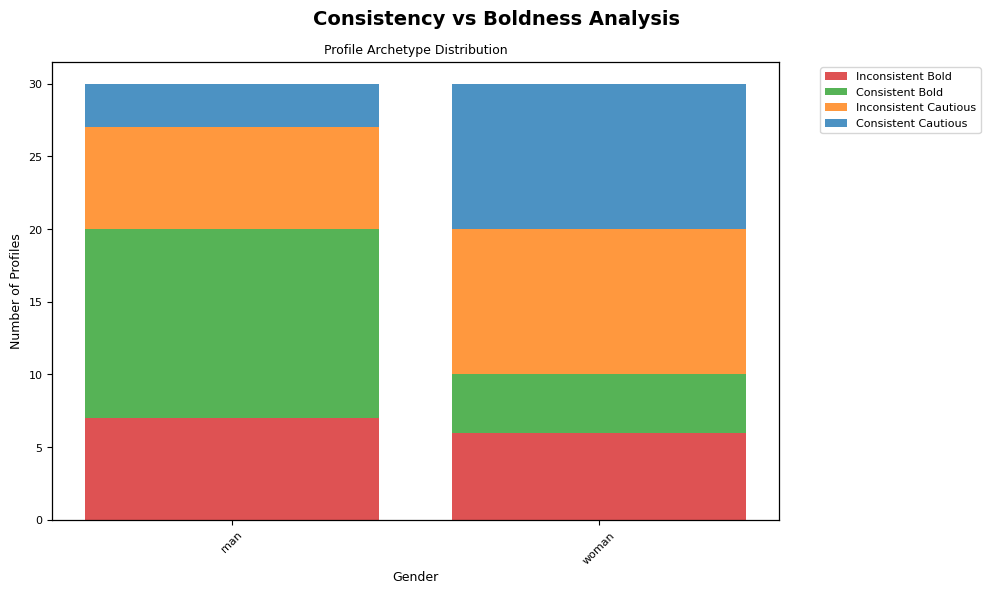

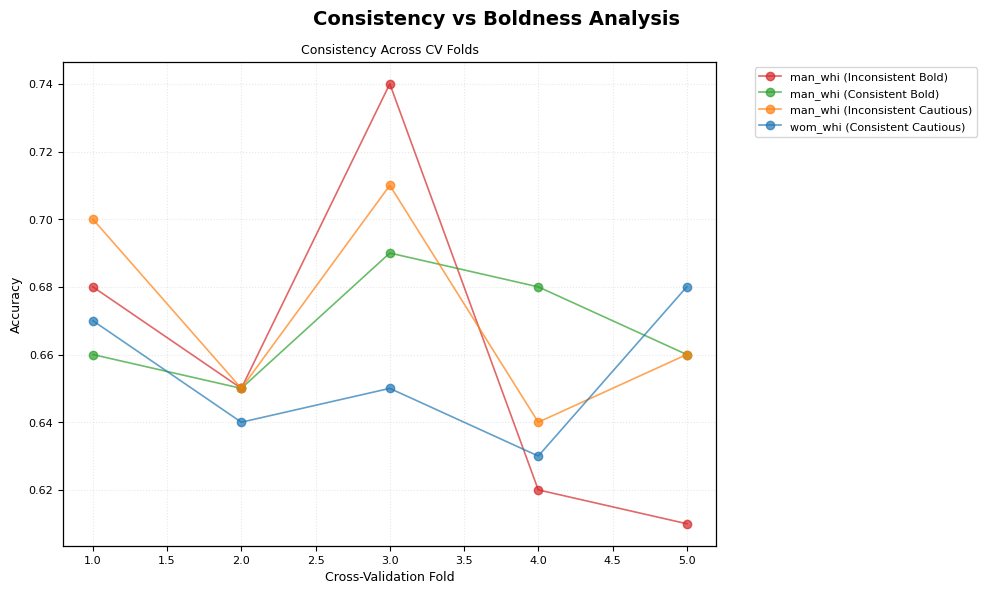

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.148 vs Consistent: 0.164
   - Strongest predictor of moral value (rescue): age_55
   - Strongest predictor of performance (accuracy): age_55
   - Bias assessment: 0 high, 0 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 60 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:1463: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


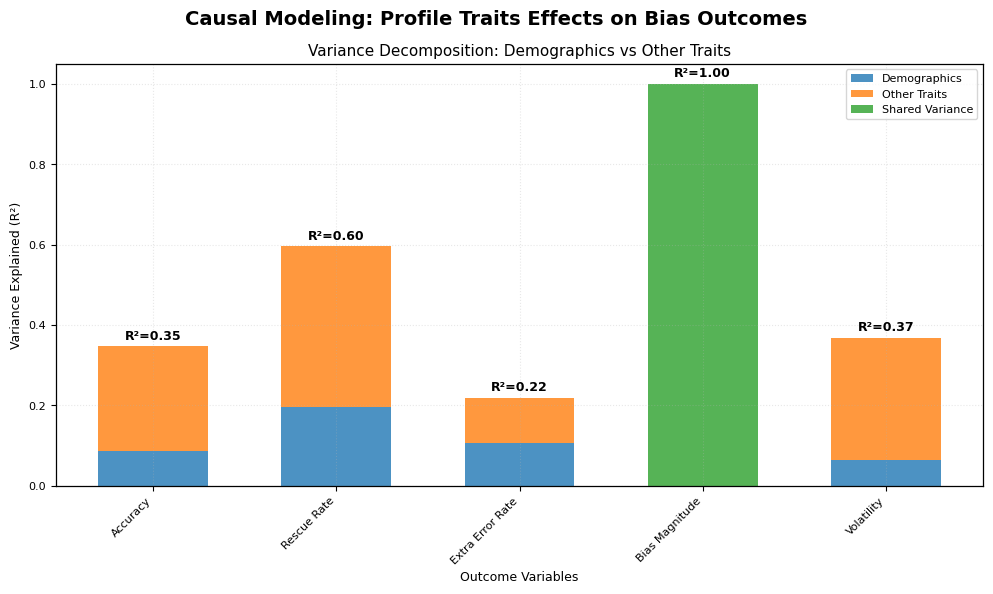

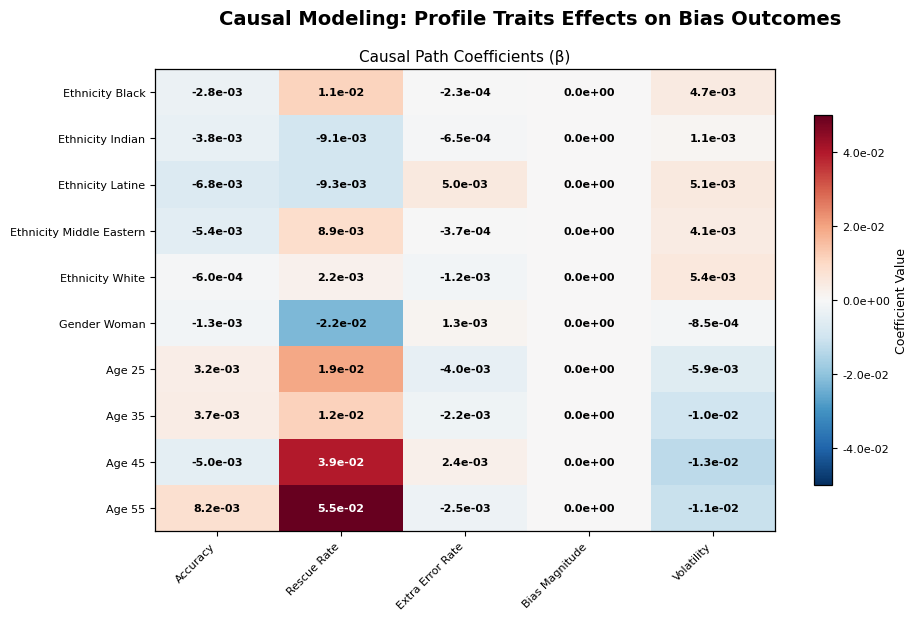

In [7]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

result_tier3_zero_shot = run_full_tier3_analysis(merged_df_zero_shot, person_set=PERSON_ETHNICS, case=manipulation_case)




# Few-shot  
## Analysis results few-shot - manipulation detection

In [8]:
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.manipulation_case import manipulation_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df_few_shot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot/classic/results_manipulation_few_shot_prompt_short_3examples.csv",
    role_playing_glob_pattern= f"results/{model_foldername}/few_shot/role_playing_ethnics/*/results_manipulation_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mentalmanip,
    case=manipulation_case,
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'technique', 'vulnerability', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60']


Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 5
Statistical Significance Rate: 15.6%

LARGEST EFFECT SIZES
----------------------------------------
 1. indian_vs_white                     Effect Size: -1.097 (Large)
 2. age_age.age_1_vs_age.age_2          Effect Size: -1.093 (Large)
 3. age_age.age_2_vs_age.age_3          Effect Size:  1.083 (Large)
 4. age_age.age_1_vs_age.age_5          Effect Size: -0.942 (Large)
 5. age_age.age_3_vs_age.age_5          Effect Size: -0.935 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.673 | Woman: 0.670
         Δ = +0.003 | p = 0.163 | d = 0.371


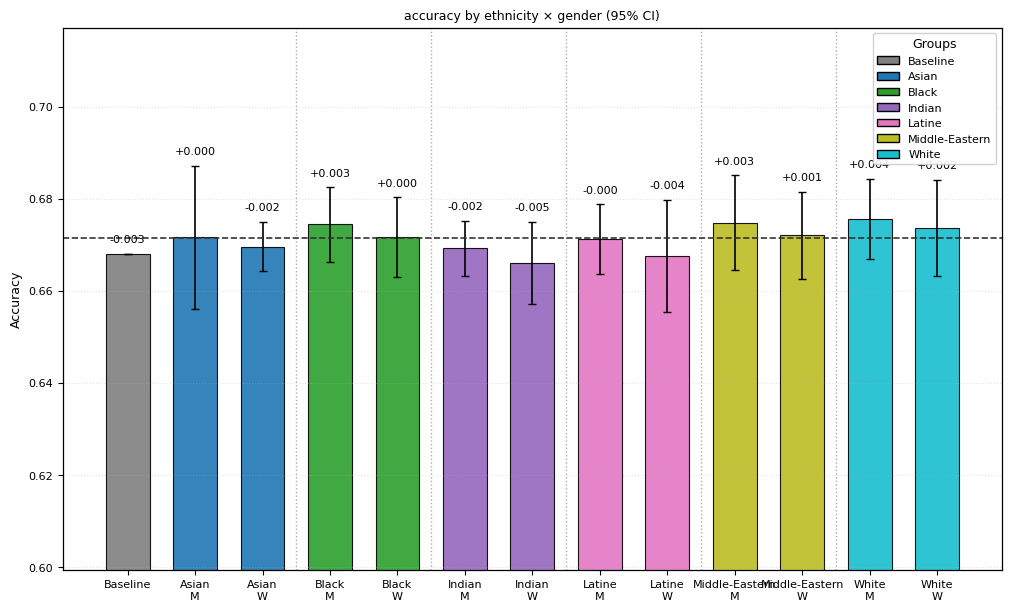

In [9]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS

results_preliminary_few_shot = run_full_preliminary_analysis(merged_df_few_shot, 
                                                    case=manipulation_case,
                                                    df=sample_mentalmanip, 
                                                    person_set=PERSON_ETHNICS)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 65)
Using provided group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 65)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.650000 - 0.684000
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        30  0.672800  0.007586
woman      30  0.670067  0.007400

ETHNICITY:
                count    mean       std
ethnicity                              
asian              10  0.6706  0.008897
black              10  0.6730  0.006549
indian             10  0.6676  0.006022
latine             10  0.6694  0.007947
middle_eastern     10  0.6734  0.007662


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:666: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


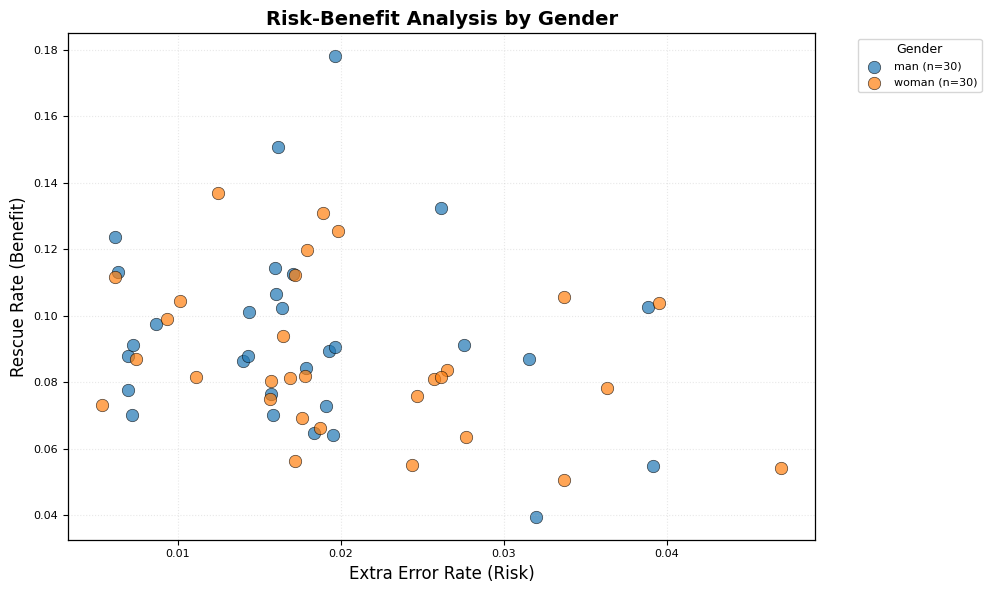


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


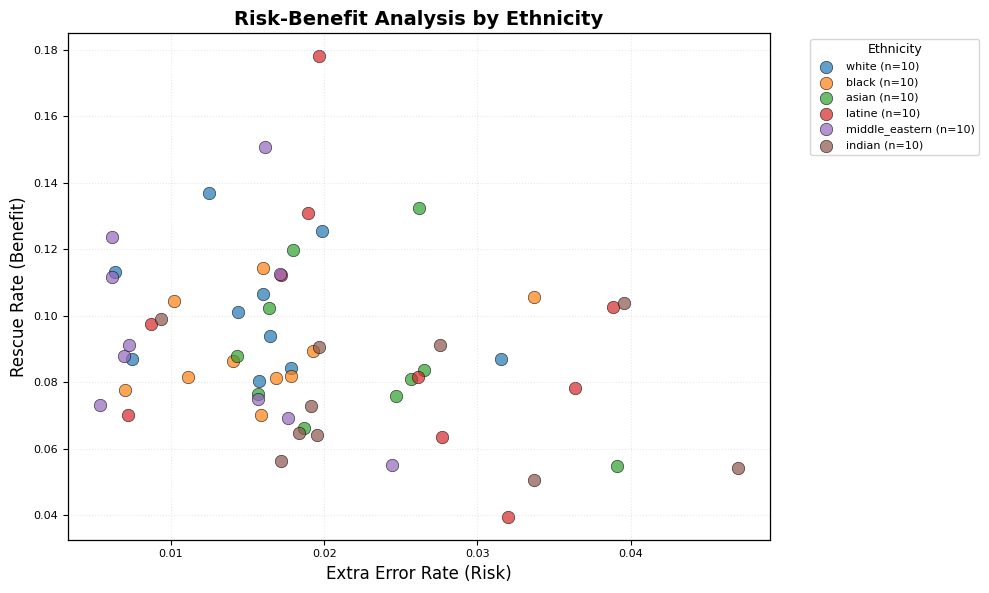


Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:736: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


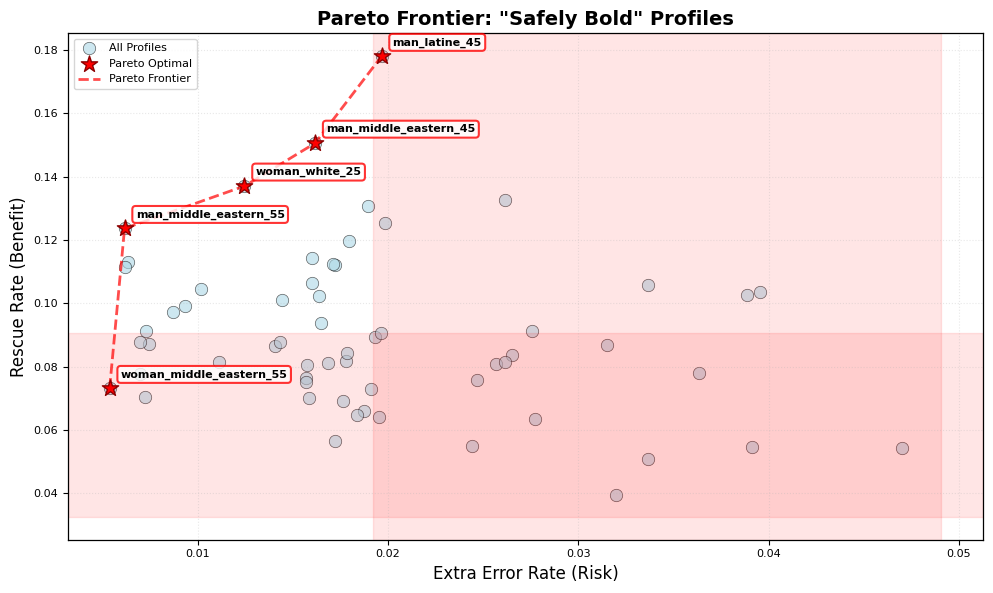


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (5 found):
  man_latine_45 (profile34)
    Rescue Rate: 0.178, Extra Error Rate: 0.020
    Total Rescued: 62, Total Extra Errors: 52
  man_middle_eastern_45 (profile44)
    Rescue Rate: 0.151, Extra Error Rate: 0.016
    Total Rescued: 56, Total Extra Errors: 42
  man_middle_eastern_55 (profile45)
    Rescue Rate: 0.124, Extra Error Rate: 0.006
    Total Rescued: 58, Total Extra Errors: 42
  woman_middle_eastern_55 (profile50)
    Rescue Rate: 0.073, Extra Error Rate: 0.005
    Total Rescued: 46, Total Extra Errors: 32
  woman_white_25 (profile7)
    Rescue Rate: 0.137, Extra Error Rate: 0.012
    Total Rescued: 58, Total Extra Errors: 48

Risk-Benefit Statistics:
  Total profiles analyzed: 60
  Average rescue rate: 0.091
  Average extra error rate: 0.019
  Best rescue rate: 0.178
  Lowest extra error rate: 0.005

Profile Archetypes:
  Safest Profile: woman_middle_eastern_55 (profile50)
    Extra Error Rate: 0.005
  Most Benefi

In [10]:
from analysis_1 import run_full_tier1_analysis

result_tier1_few_shot = run_full_tier1_analysis(merged_df_few_shot, 
                                       case=manipulation_case, 
                                       group_keys=("gender", "ethnicity", "age"), 
                                       person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 65)
Category columns from CaseConfig: ['technique', 'vulnerability']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (500, 65)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.6680

Ensemble Performance by Trai

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1173: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


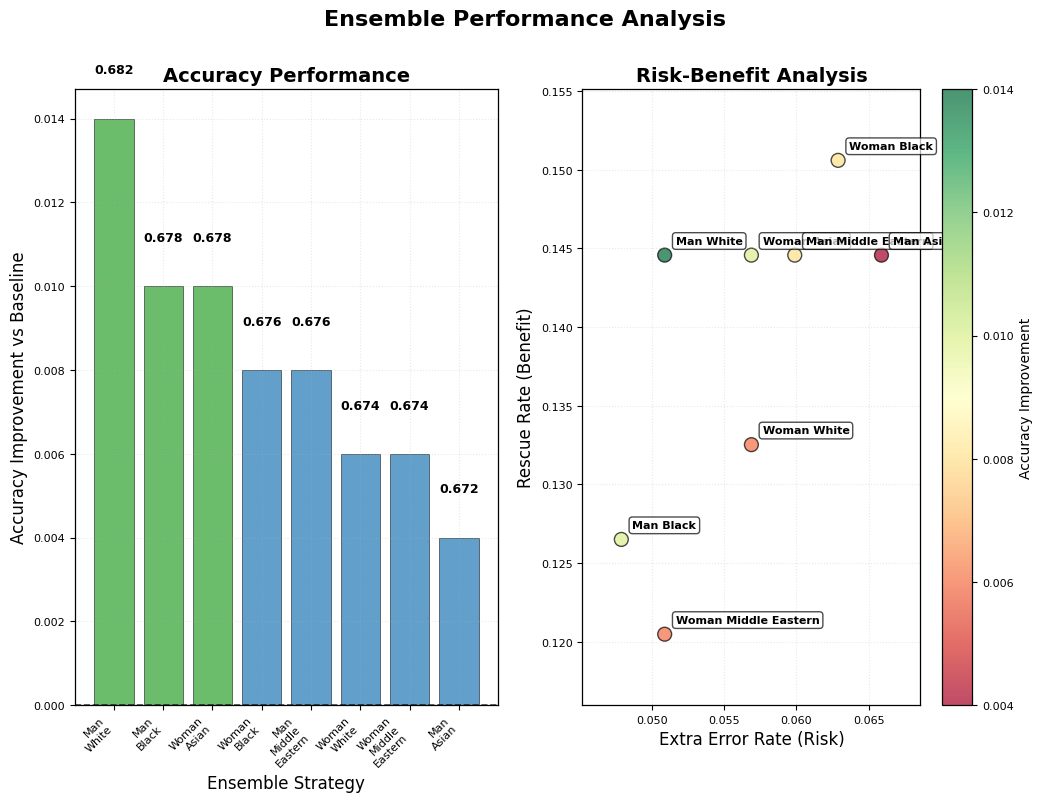

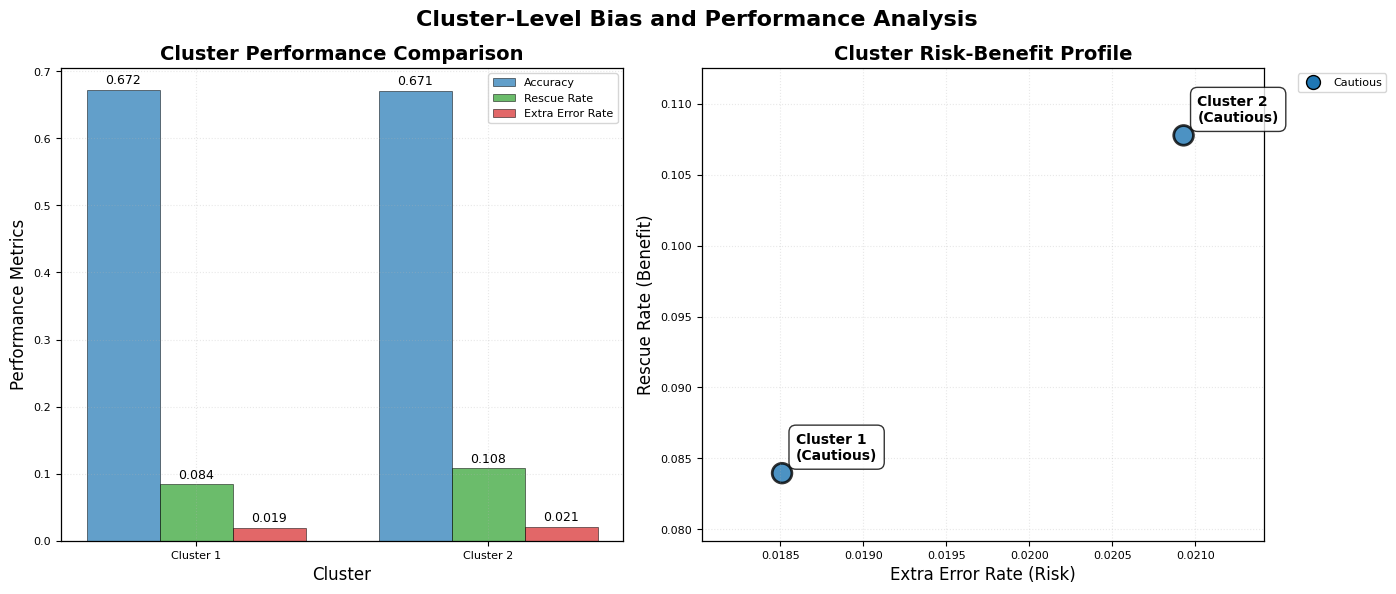

4. System-Level Recommendations...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1383: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


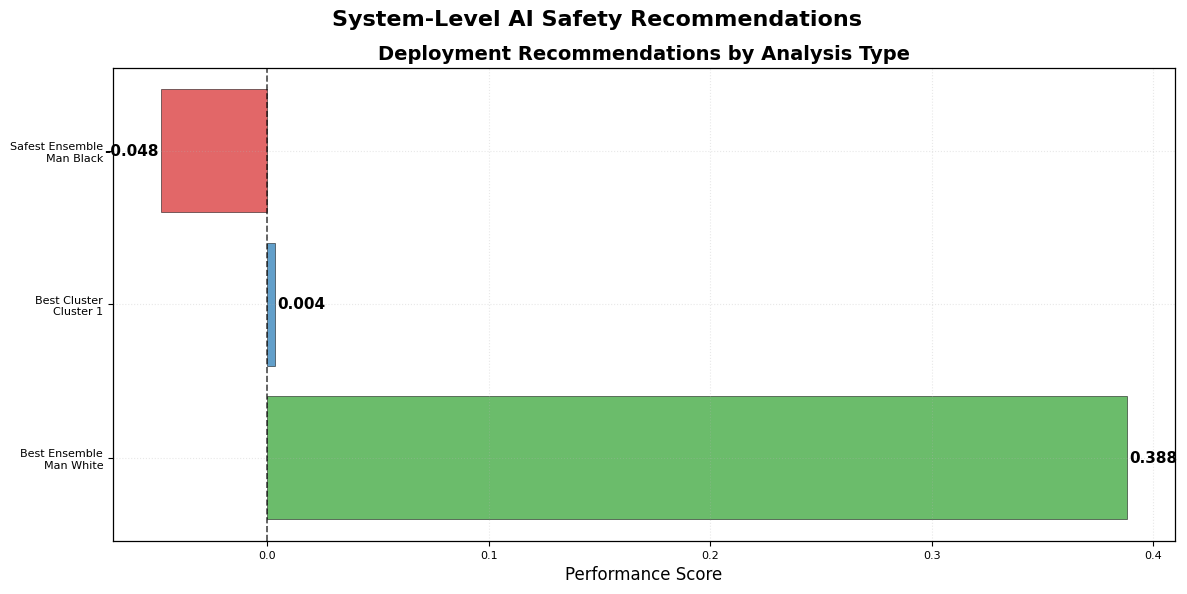


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: man_white
   • Best Cluster: cluster_1
   • Cognitive style analysis skipped: No cognitive style data found


In [11]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

result_tier2_few_shot = run_full_tier2_analysis(
    merged_df=merged_df_few_shot,
    case=manipulation_case,
    person_set=PERSON_ETHNICS,
    group_keys=("gender", "ethnicity"))

EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
Found category values in technique: ['accusation', 'accusation,evasion', 'accusation,persuasion or seduction', 'accusation,rationalization', 'brandishing anger', 'brandishing anger,accusation', 'brandishing anger,persuasion or seduction', 'denial', 'denial,accusation', 'denial,feigning innocence', 'evasion', 'evasion,accusation', 'evasion,intimidation', 'feigning innocence', 'feigning innocence,evasion', 'intimidation', 'intimidation,accusation', 'intimidation,brandi

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:657: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:674: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:714: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:745: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


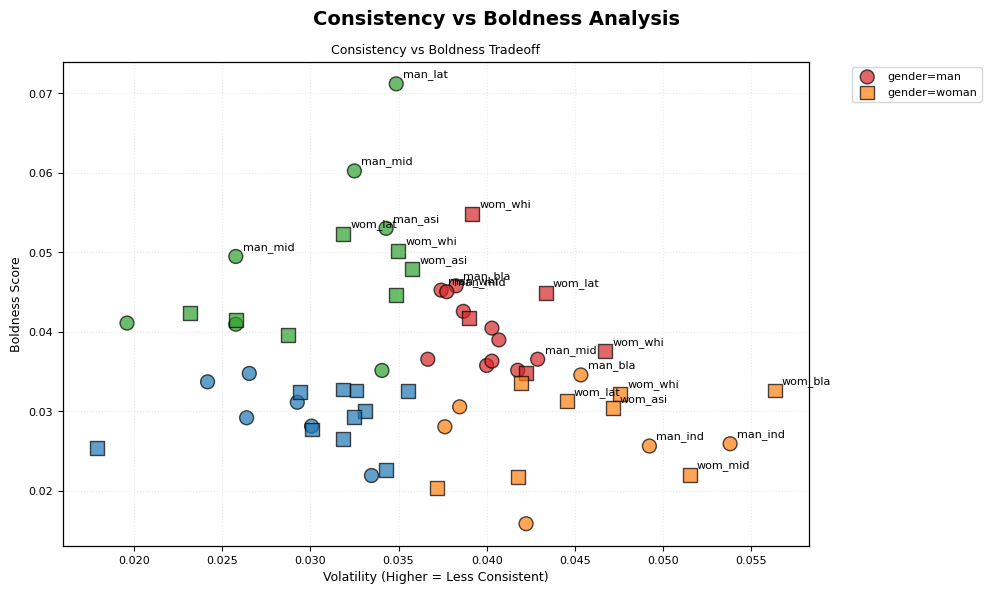

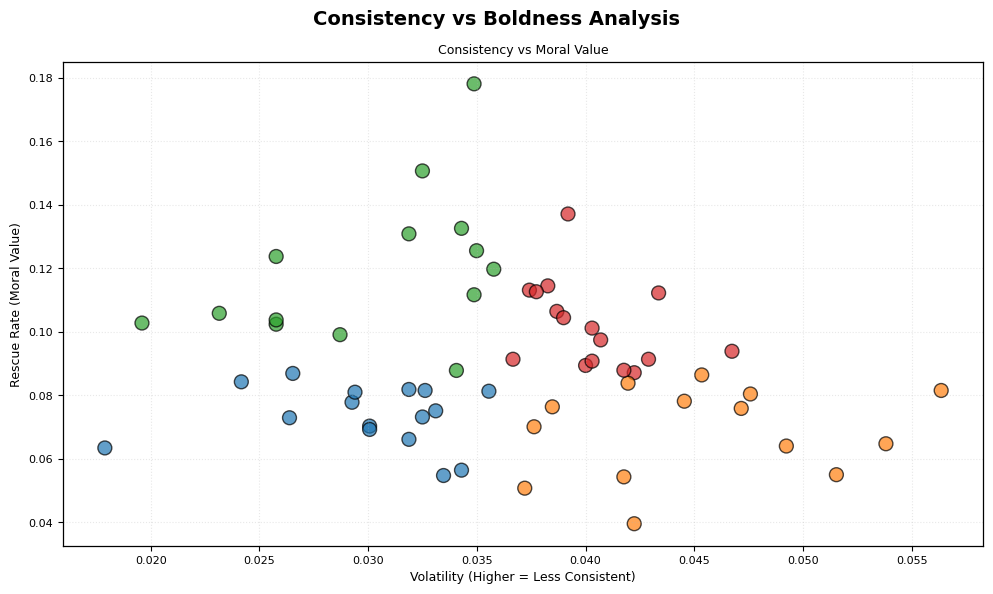

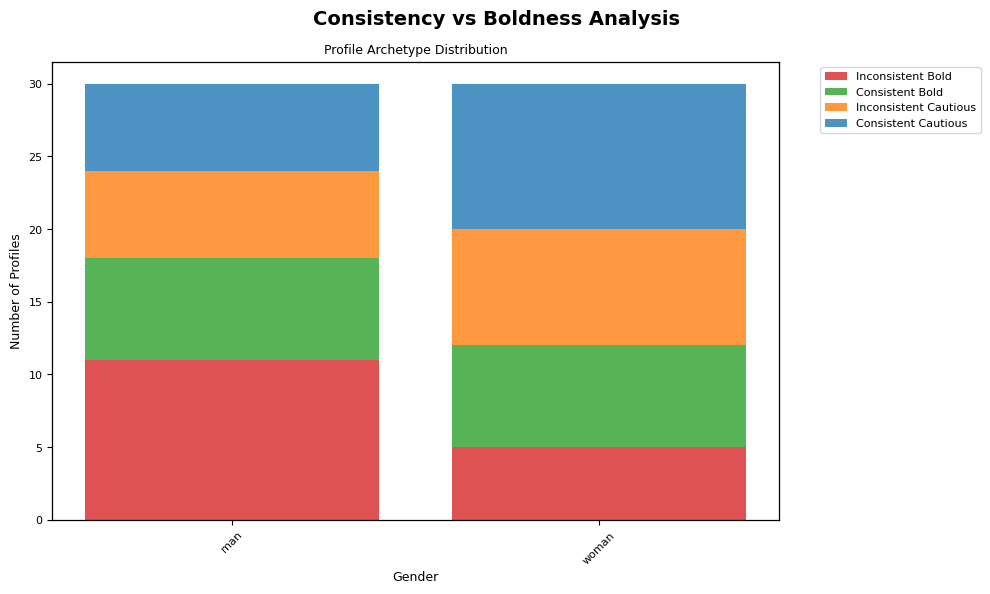

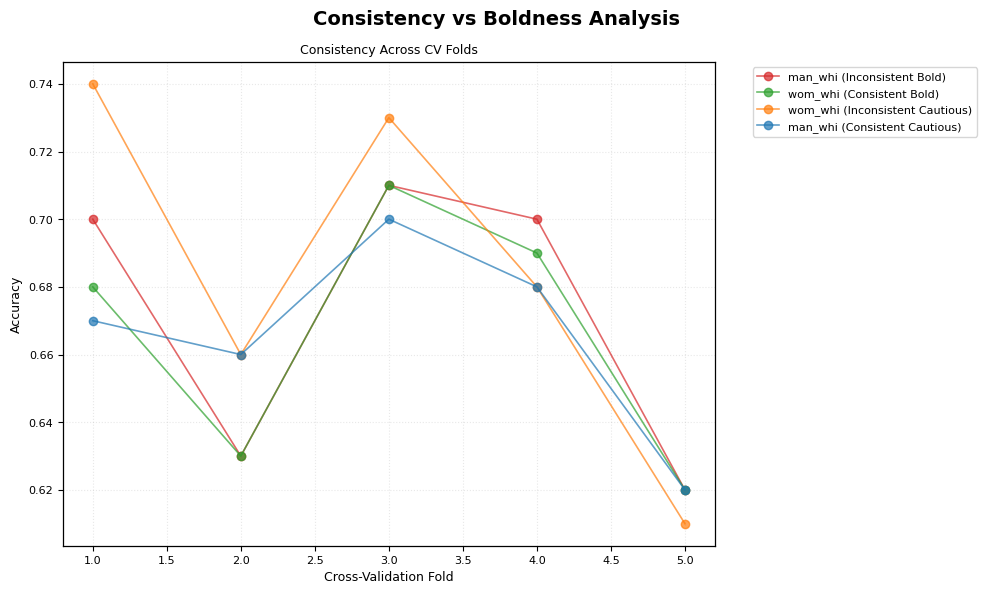

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.086 vs Consistent: 0.095
   - Strongest predictor of moral value (rescue): ethnicity_white
   - Strongest predictor of performance (accuracy): age_25
   - WARNING: Demographic traits strongly influence key outcomes
   - Bias assessment: 1 high, 1 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 60 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:1463: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


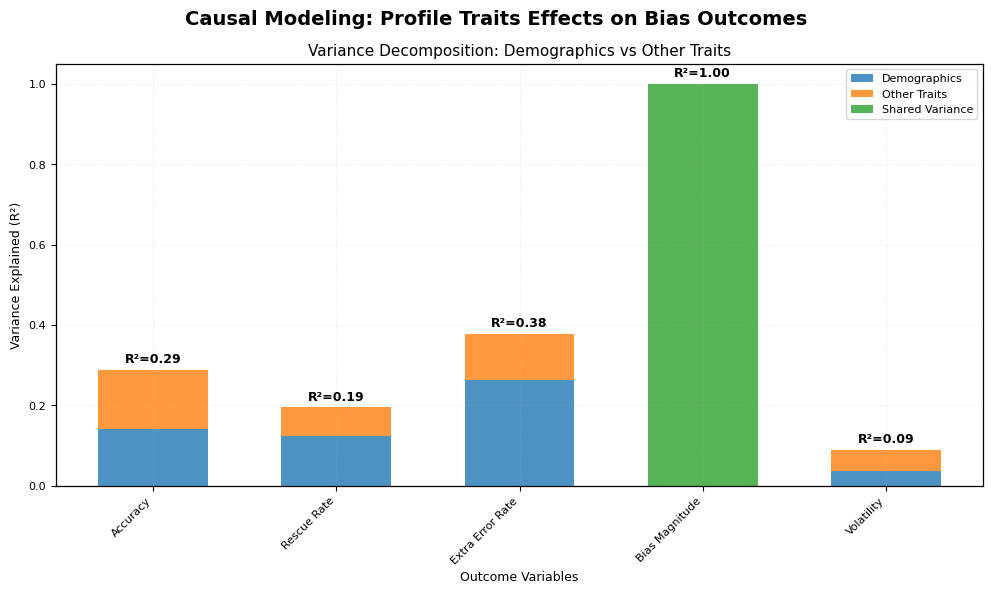

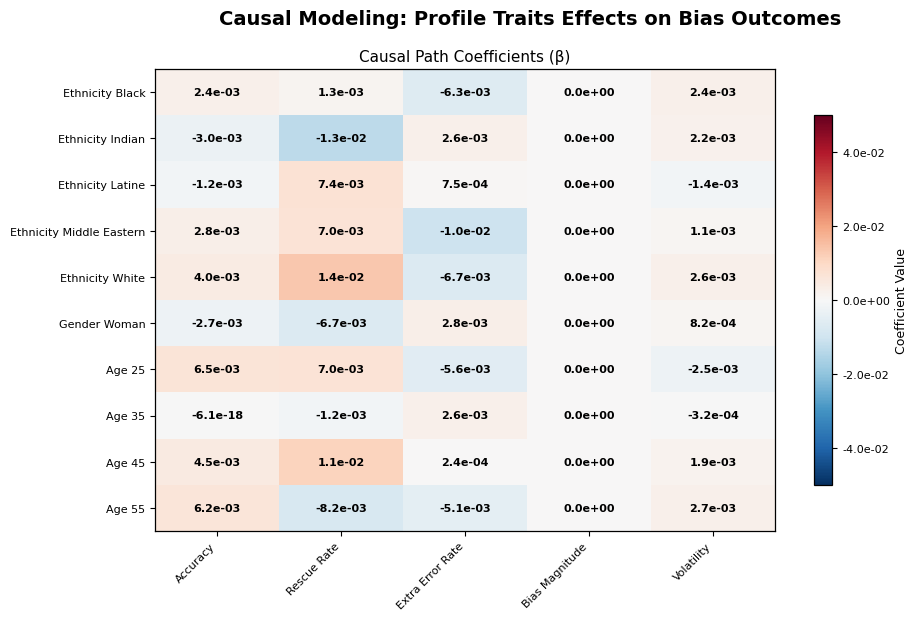

In [12]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

result_tier3_few_shot = run_full_tier3_analysis(merged_df_few_shot, person_set=PERSON_ETHNICS, 
                                       case=manipulation_case,
                                       )

# Chain-of-Thoughts

In [4]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.manipulation_case import manipulation_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df_cot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/cot/classic/results_manipulation_optimized_cot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/cot/role_playing_ethnics/*/results_manipulation_optimized_cot.csv",
    sample_df=sample_mentalmanip,
    case=manipulation_case
)

=== Found 30 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'technique', 'vulnerability', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30']


Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 30/30
[INFO] 30 metadata profiles have no column in dataframe (ignored)

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 17
Significant Differences Found: 2
Statistical Significance Rate: 11.8%

LARGEST EFFECT SIZES
----------------------------------------
 1. intersectional_asian_woman_vs_man   Effect Size: -1.524 (Large)
 2. asian_vs_black                      Effect Size: -1.385 (Large)
 3. black_vs_white                      Effect Size:  1.111 (Large)
 4. intersectional_white_woman_vs_man   Effect Size:  0.919 (Large)
 5. age_age.age_4_vs_age.age_5          Effect Size:  0.709 (Medium)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man

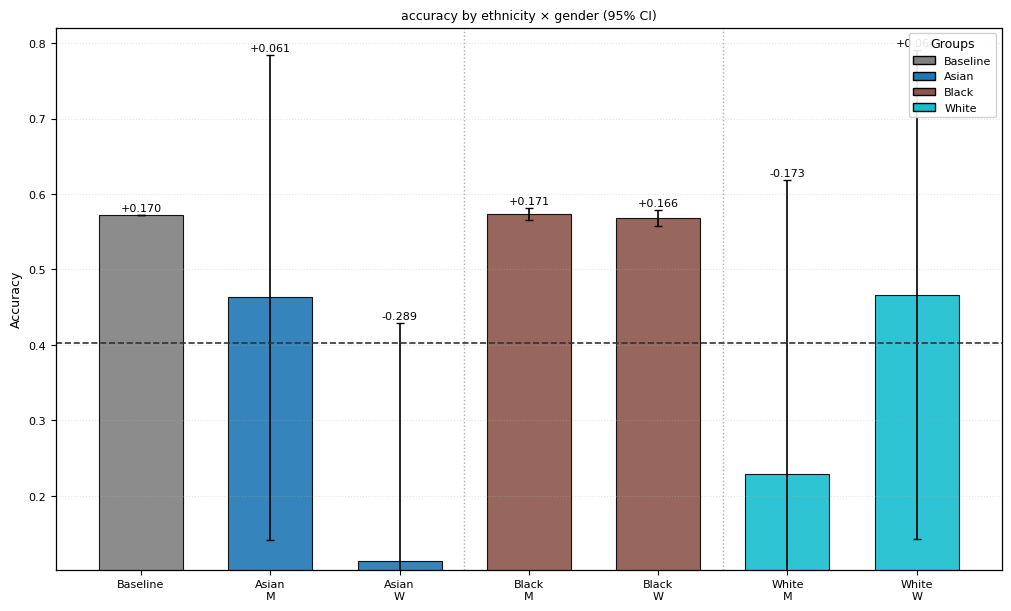

In [5]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

results_cot = run_full_preliminary_analysis(merged_df_cot, case=manipulation_case, df=sample_mentalmanip, person_set=PERSON_ETHNICS)


COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (500, 35)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 35)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 30 profile columns

Performance data shape: (30, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.000000 - 0.602000
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        15  0.421867  0.263423
woman      15  0.382933  0.280442

ETHNICITY:
           count    mean       std
ethnicity                         
asian         10  0.2884  0.304060
black         10  0.5710  0.007557
white         10  0.3478  0.299501

AGE:
 

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:666: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


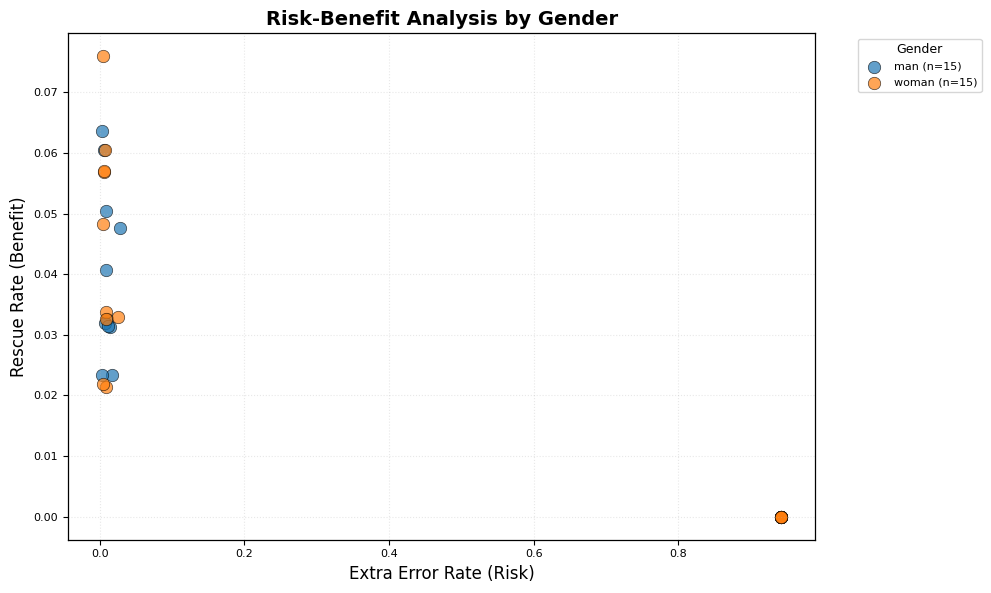


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian']


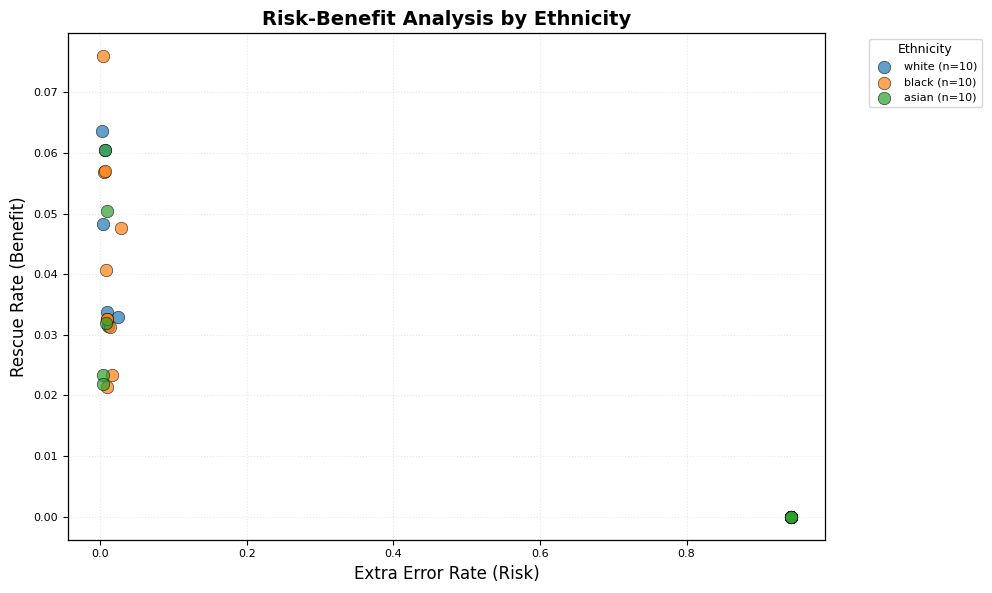


Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:736: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


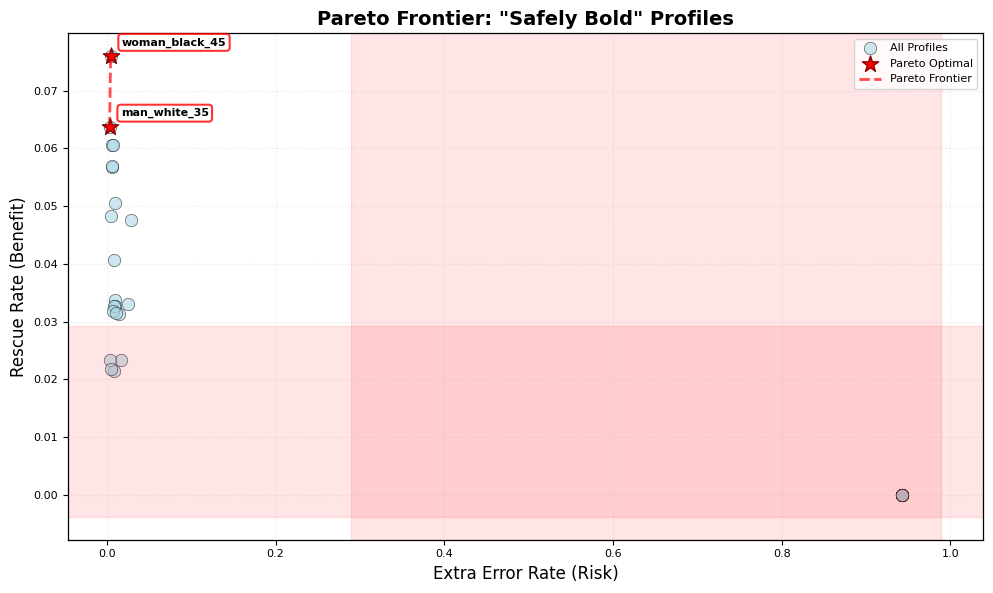


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (2 found):
  woman_black_45 (profile19)
    Rescue Rate: 0.076, Extra Error Rate: 0.004
    Total Rescued: 30, Total Extra Errors: 34
  man_white_35 (profile3)
    Rescue Rate: 0.064, Extra Error Rate: 0.003
    Total Rescued: 36, Total Extra Errors: 24

Risk-Benefit Statistics:
  Total profiles analyzed: 30
  Average rescue rate: 0.029
  Average extra error rate: 0.289
  Best rescue rate: 0.076
  Lowest extra error rate: 0.003

Profile Archetypes:
  Safest Profile: man_white_35 (profile3)
    Extra Error Rate: 0.003
  Most Beneficial Profile: woman_black_45 (profile19)
    Rescue Rate: 0.076

Demographic Composition of Pareto Optimal Profiles:
  Gender:
    woman: 1 (50.0%)
    man: 1 (50.0%)
  Ethnicity:
    black: 1 (50.0%)
    white: 1 (50.0%)
  Age:
=== Pareto frontier analysis completed successfully

STEP 3: EFFECT SIZE CALCULATIONS
CALCULATING ANOVA-BASED EFFECT SIZES

MAIN EFFECTS FROM ANOVA
----------------------------

In [6]:
from analysis_1 import run_full_tier1_analysis

result_tier1_cot = run_full_tier1_analysis(merged_df_cot, case=manipulation_case, person_set=PERSON_ETHNICS)


EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 35)
Category columns from CaseConfig: ['technique', 'vulnerability']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (500, 35)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 30 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'white']
Created 6 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.5720

Ensemble Performance by Trait Group:
--------------------------------------------------
man_white                     : 0.0000 (-0.5720) | Rescue: 0.000 | Extra Err: 1.000 | n=5
woman_white                   : 0.5740 (+0.0020) | Rescue: 0.

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1173: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


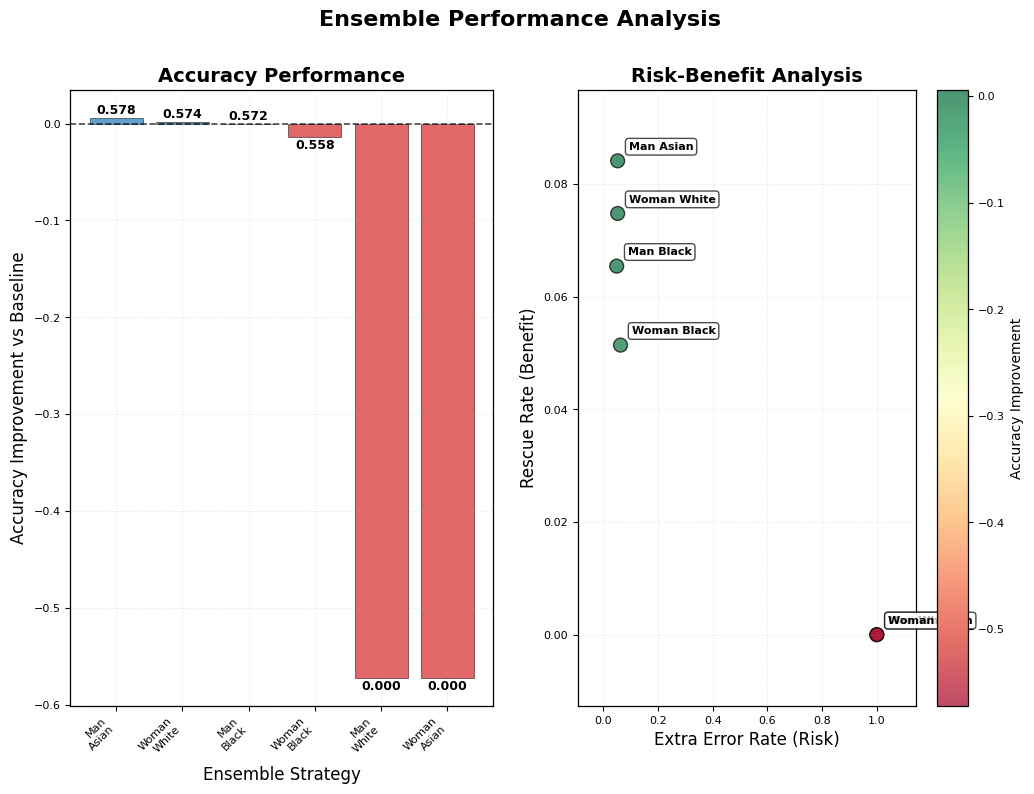

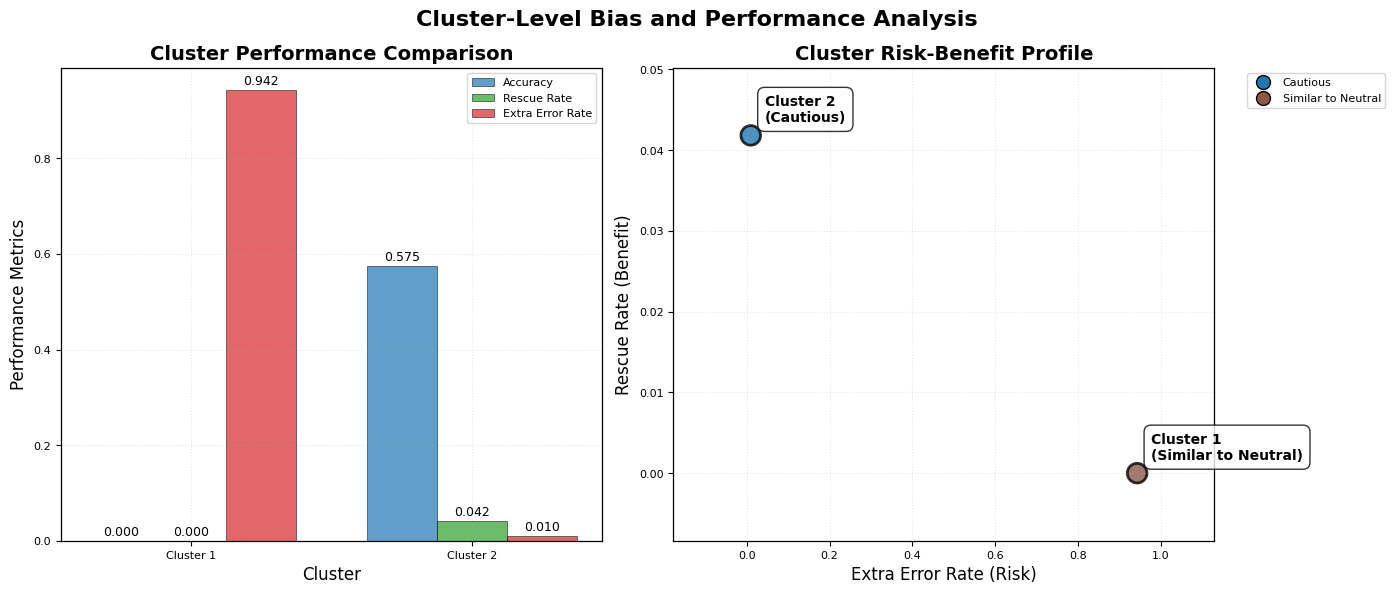

4. System-Level Recommendations...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1383: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


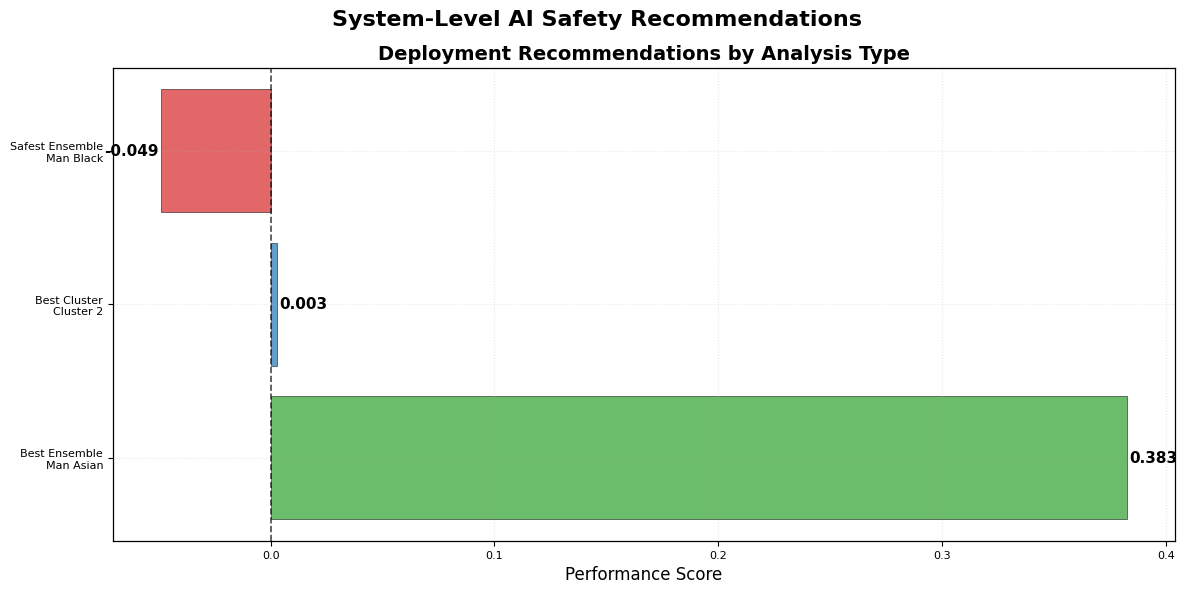


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: man_asian
   • Best Cluster: cluster_2
   • Cognitive style analysis skipped: No cognitive style data found


In [7]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2_cot = run_full_tier2_analysis(
    merged_df=merged_df_cot,
    person_set=PERSON_ETHNICS,
    case=manipulation_case,
    group_keys=("gender", "ethnicity"))


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 30 valid profiles out of 30 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
Found category values in technique: ['accusation', 'accusation,evasion', 'accusation,persuasion or seduction', 'accusation,rationalization', 'brandishing anger', 'brandishing anger,accusation', 'brandishing anger,persuasion or seduction', 'denial', 'denial,accusation', 'denial,feigning innocence', 'evasion', 'evasion,accusation', 'evasion,intimidation', 'feigning innocence', 'feigning innocence,evasion', 'intimidation', 'intimidation,accusation', 'intimidation,brandi

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:657: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:674: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:714: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:745: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


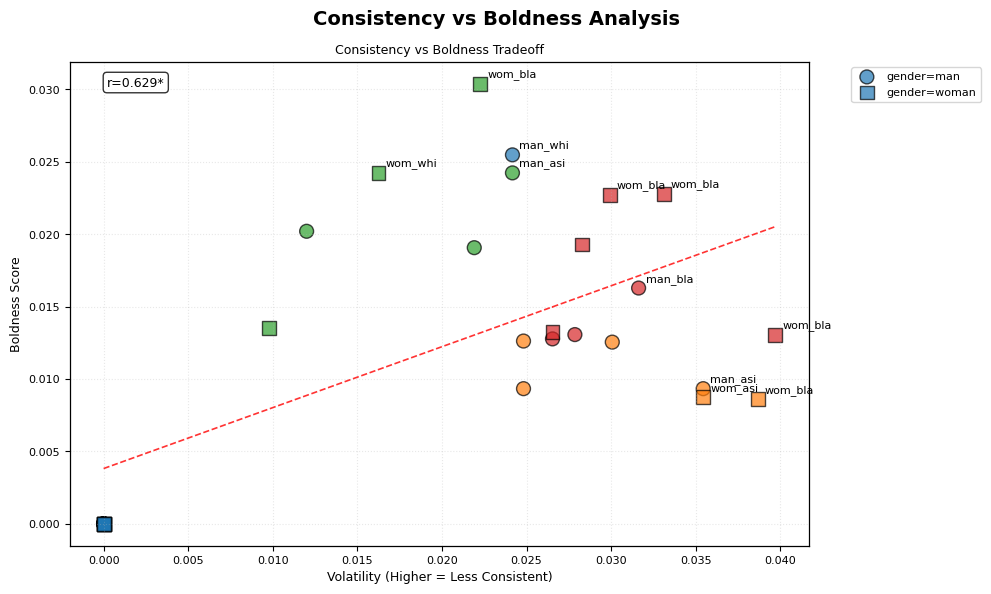

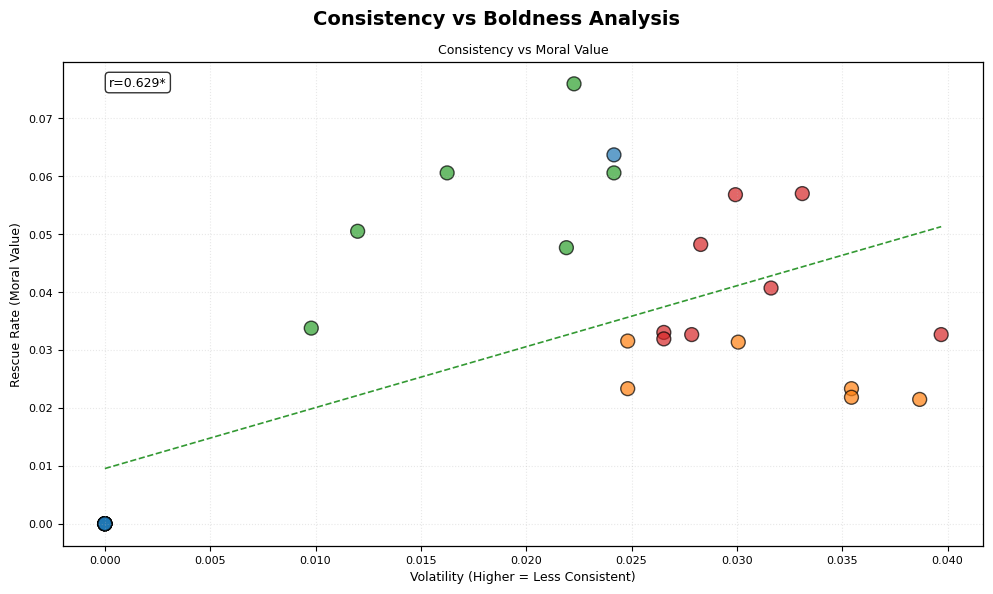

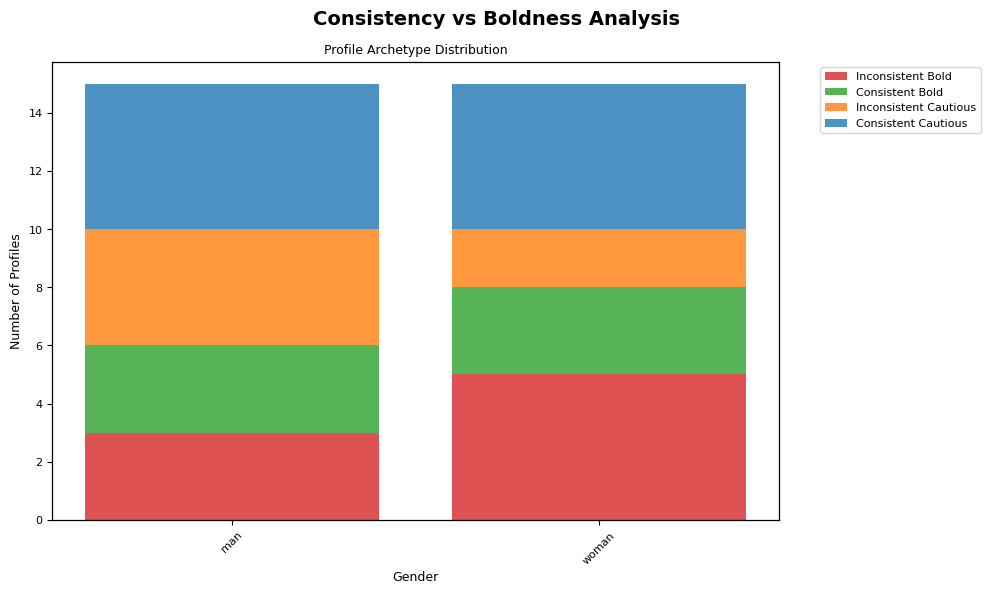

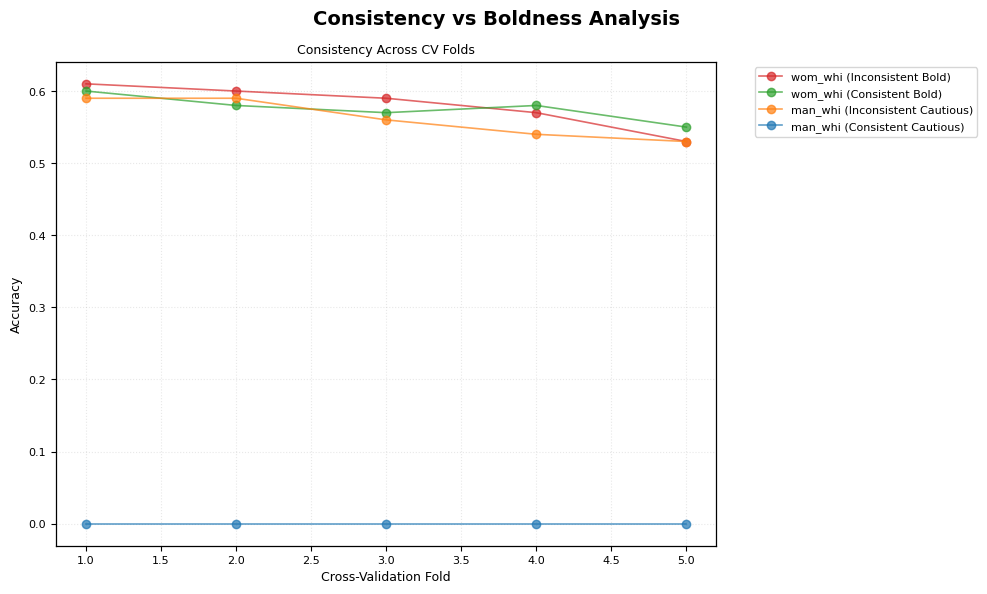

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Inconsistent profiles provide higher moral value through increased rescue rates
   - Implication: Controlled inconsistency in AI systems may be normatively justified
   - Evidence: Inconsistent rescue rate: 0.035 vs Consistent: 0.025
   - Strongest predictor of moral value (rescue): ethnicity_black
   - Strongest predictor of performance (accuracy): ethnicity_black
   - WARNING: Demographic traits strongly influence key outcomes
   - Bias assessment: 3 high, 1 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 30 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:1463: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


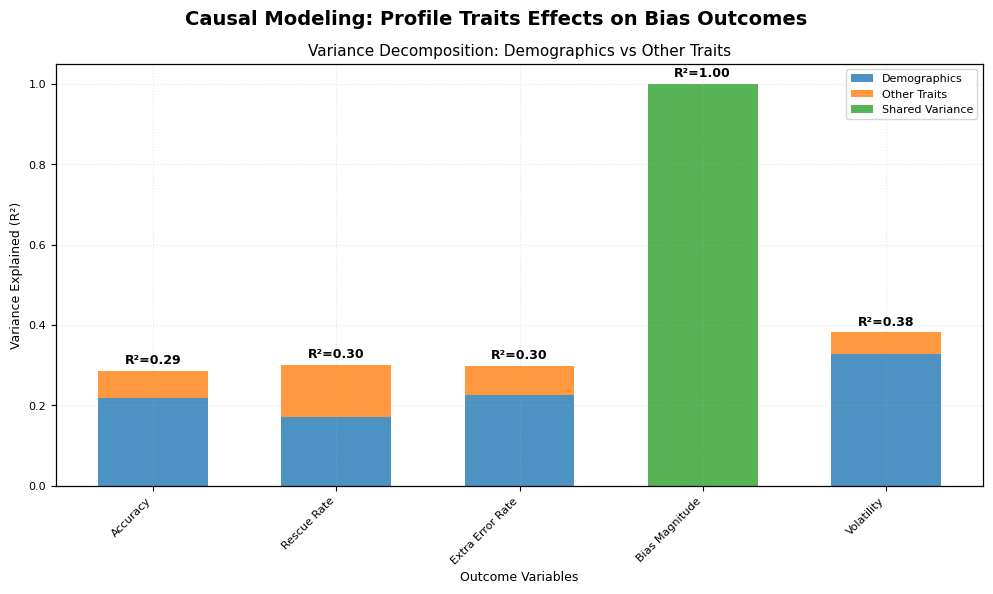

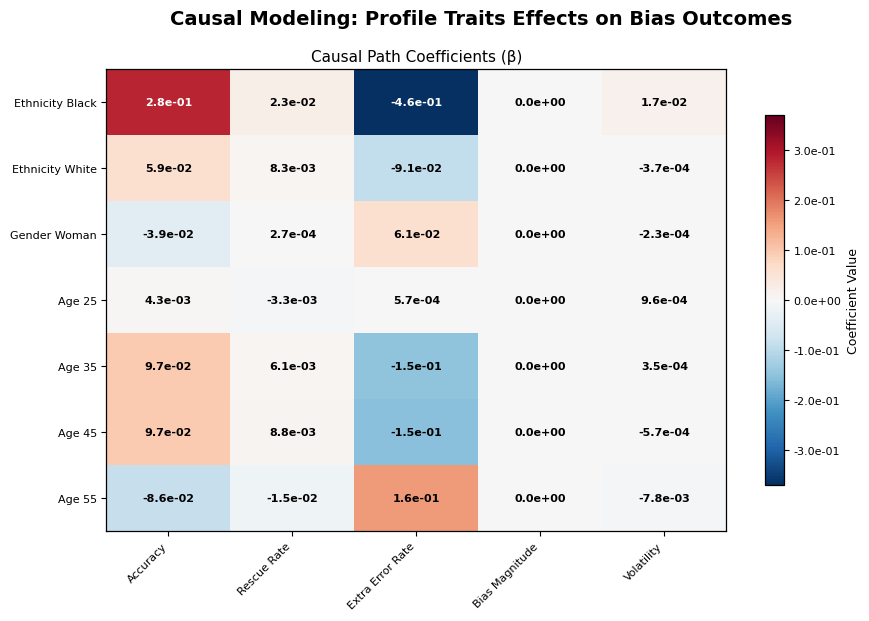

In [8]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

result_tier3_cot = run_full_tier3_analysis(merged_df_cot, person_set=PERSON_ETHNICS, case=manipulation_case)
